# BCECF Ratiometric pH Calibration

Estimate pH in myTXTL cell-free reactions from BCECF fluorescence.

BCECF is a ratiometric pH dye: its emission at 535 nm is excited at two
wavelengths (490 nm, 440 nm). The ratio of those reads (`490/440`) tracks pH
independently of absolute dye concentration.

This analysis uses the [Nucleus CDK](https://pypi.org/project/nucleus-cdk/)
plate-reader pipeline:

1. Load the calibration plate (BCECF standards at known pH)
2. Compute the `490/440` ratio and fit a standard curve
3. Load the kinetic data plate
4. Standardize fluorescence ratio to pH via the curve
5. Fit kinetics with a sigmoid + drift + baseline-offset model

> **Install note.** `nucleus-cdk` declares `pyarrow>=18,<19`, and pyarrow
> publishes no cp314 wheels, so a plain `pip install` fails on Python 3.14.
> Nothing in `cdk` imports pyarrow, so we install with `--no-deps`; the
> packages the CDK actually uses come from `environment.yml`.

In [14]:
!pip install --no-deps nucleus-cdk==0.6.0rc2

# Surface a failed install here, rather than as a confusing ModuleNotFoundError
# in the import cell below.
import importlib.metadata as md
assert md.version("nucleus-cdk") == "0.6.0rc2", f"got {md.version('nucleus-cdk')}"
print("nucleus-cdk", md.version("nucleus-cdk"))

nucleus-cdk 0.6.0rc2


In [15]:
%load_ext autoreload
%autoreload 2

import pandas as pd

from cdk import logging
log = logging.setup_logging(logging.ERROR)

from cdk.instruments.platereader import load_platereader_data

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load calibration data

Gen5-exported endpoint data paired with a platemap. The platemap specifies the
pH of each standard in a `pH` column, and marks the standard wells with
`Name == "BCECF standard"`.

In [16]:
cal = load_platereader_data(
    data_file="2026_3_10 BCECF pH measurement Calibration.xlsx",
    platemap_file="2026_3_10 BCECF pH measurement Calibration Platemap.csv",
    platereader="biotek",
)
print(cal)

PlateReaderResult with the following 1 blocks:
0: (24, 35) endpoint read with reads: 440,535 (Fluorescence), 490,535 (Fluorescence) (Plate 'Plate 5')


                    INFO     Parsing plate block 1                 biotek.py:190


                    INFO     Read metadata section, found 1 read   biotek.py:276
                             block(s).                                          


                    WARNING  Failed to parse the data grid:       biotek.py:1430
                             Duplicate names are not allowed.                   


                    WARNING  Parsed data grid did not contain any  biotek.py:334
                             data.                                              


...

                    WARNING  Failed to parse the data grid:       biotek.py:1430
                             Duplicate names are not allowed.                   


                    WARNING  Parsed data grid did not contain any  biotek.py:334
                             data.                                              


                    INFO     Parsed 1 segment(s) successfully.     biotek.py:406


                    INFO     Found 0 segment(s) that could not be  biotek.py:407
                             associated with existing read data.                


PlateReaderResult with the following 1 blocks:
0: (24, 35) endpoint read with reads: 440,535 (Fluorescence), 490,535 (Fluorescence) (Plate 'Plate 5')


In [17]:
# Take the block we want for further analysis
calibration_data = cal[0]

## 2. Calibration curve

Compute the BCECF ratio (`490,535 / 440,535`) and fit a standard curve over the
`"BCECF standard"` wells — a linear regression of `pH` against `490/440` ratio.

slope, intercept = [  2.67495596 -13.79554277]
R^2 = 0.9112


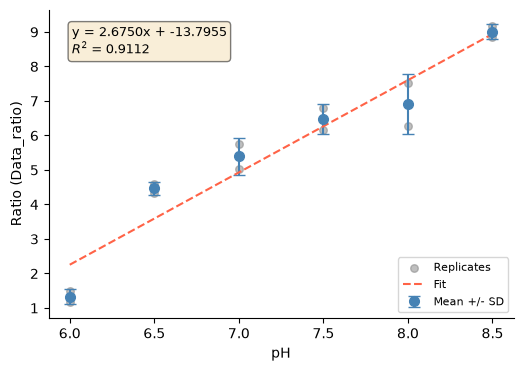

In [18]:
#| label: ph-callibration

cal_ratio = calibration_data.ratio("490,535", "440,535")
curve = cal_ratio.fit_standard_curve(known="pH", standard_name="BCECF standard")

curve.plot()
print("slope, intercept =", curve.result.params)
print("R^2 =", round(curve.result.r_squared, 4))

## 3. Load kinetic data

The 24 h kinetic run. The export contains the 440 and 490 kinetic blocks we
want plus a summary block we don't, so we select just the `kinetic` blocks.

In [19]:
sample_result = load_platereader_data(
    data_file="2026_3_25-bcecf-measurement-data.xlsx",
    platemap_file="2026_3_25-bcecf-measurement-platemap.csv",
    platereader="biotek",
)
print(sample_result)

PlateReaderResult with the following 2 blocks:
0: (2790, 38) kinetic read with reads: 440,535 (Fluorescence) (Plate 'Plate 1')
1: (2790, 38) kinetic read with reads: 490,535 (Fluorescence) (Plate 'Plate 1')


                    INFO     Parsing plate block 1                 biotek.py:190


                    INFO     Read metadata section, found 1 read   biotek.py:276
                             block(s).                                          


                    WARNING  Failed to parse the data grid: Error biotek.py:1430
                             tokenizing data. C error: Expected                 
                             14 fields in line 4, saw 33                        
                                                                                


                    WARNING  Parsed data grid did not contain any  biotek.py:334
                             data.                                              


                    INFO     Parsed 2 segment(s) successfully.     biotek.py:406


                    INFO     Found 0 segment(s) that could not be  biotek.py:407
                             associated with existing read data.                


PlateReaderResult with the following 2 blocks:
0: (2790, 38) kinetic read with reads: 440,535 (Fluorescence) (Plate 'Plate 1')
1: (2790, 38) kinetic read with reads: 490,535 (Fluorescence) (Plate 'Plate 1')


In [20]:
sample_data = sample_result.take("kinetic")

## 4. Convert to pH and fit kinetics

Compute the `490/440` ratio on the data plate, then `standardize(curve)` to
estimate pH from that ratio.

pH traces sit on a non-zero baseline (~6–8), so we fit `sigmoid_drift_offset` —
a sigmoid with a linear drift term **and** a fitted constant baseline `c`. The
plain `sigmoid_drift` model has no constant term and would mis-estimate both
steady state and maximum velocity on a pH trace.

In [21]:
pH = sample_data.ratio("490,535", "440,535").standardize(curve)
kinetics = pH.fit_kinetics(fit_function_name="sigmoid_drift_offset")
kinetics.summary

,Well,Name,Max Velocity,Max Velocity Time,Lag Time,Steady State,Completion Time,Completion Threshold,Drift,Offset,Fit Function,R^2,Good Fit,Standardized to
0,C4,No DNA,0.06,0 days 03:10:01,-1 days +21:27:29,7.99,0 days 11:34:18,0.95,-0.00,7.29,sigmoid_drift_offset,0.99,True,pH
1,C5,No DNA,0.00,0 days 05:52:04,NaT,7.29,0 days 08:51:04,0.95,-0.01,7.29,sigmoid_drift_offset,0.34,False,pH
2,D4,No DNA,0.05,0 days 03:53:57,-1 days +22:53:34,7.91,0 days 11:16:11,0.95,0.00,7.41,sigmoid_drift_offset,0.99,True,pH
3,D5,p70a-mCherry,0.07,0 days 04:16:49,-1 days +22:42:12,8.09,0 days 12:29:27,0.95,-0.00,7.35,sigmoid_drift_offset,0.99,True,pH
4,E4,p70a-mCherry,0.06,0 days 04:59:01,0 days 00:53:24,7.88,0 days 11:00:37,0.95,0.01,7.44,sigmoid_drift_offset,0.99,True,pH
5,E5,p70a-mCherry,0.07,0 days 04:51:28,-1 days +22:49:31,8.09,0 days 13:44:20,0.95,-0.00,7.35,sigmoid_drift_offset,0.99,True,pH


`kinetics.plot()` overlays each fit on its data. Facet on `"Well"` to get one
fit per trace, matching the original analysis: the fit itself is always per-well,
but the default facet (`Name`) averages the fit parameters across the three
replicate wells and draws a single dashed line per condition.

Each panel shows the calculated pH trace (points), the model fit (dashed), the
maximum-velocity tangent, and the steady-state and completion markers.

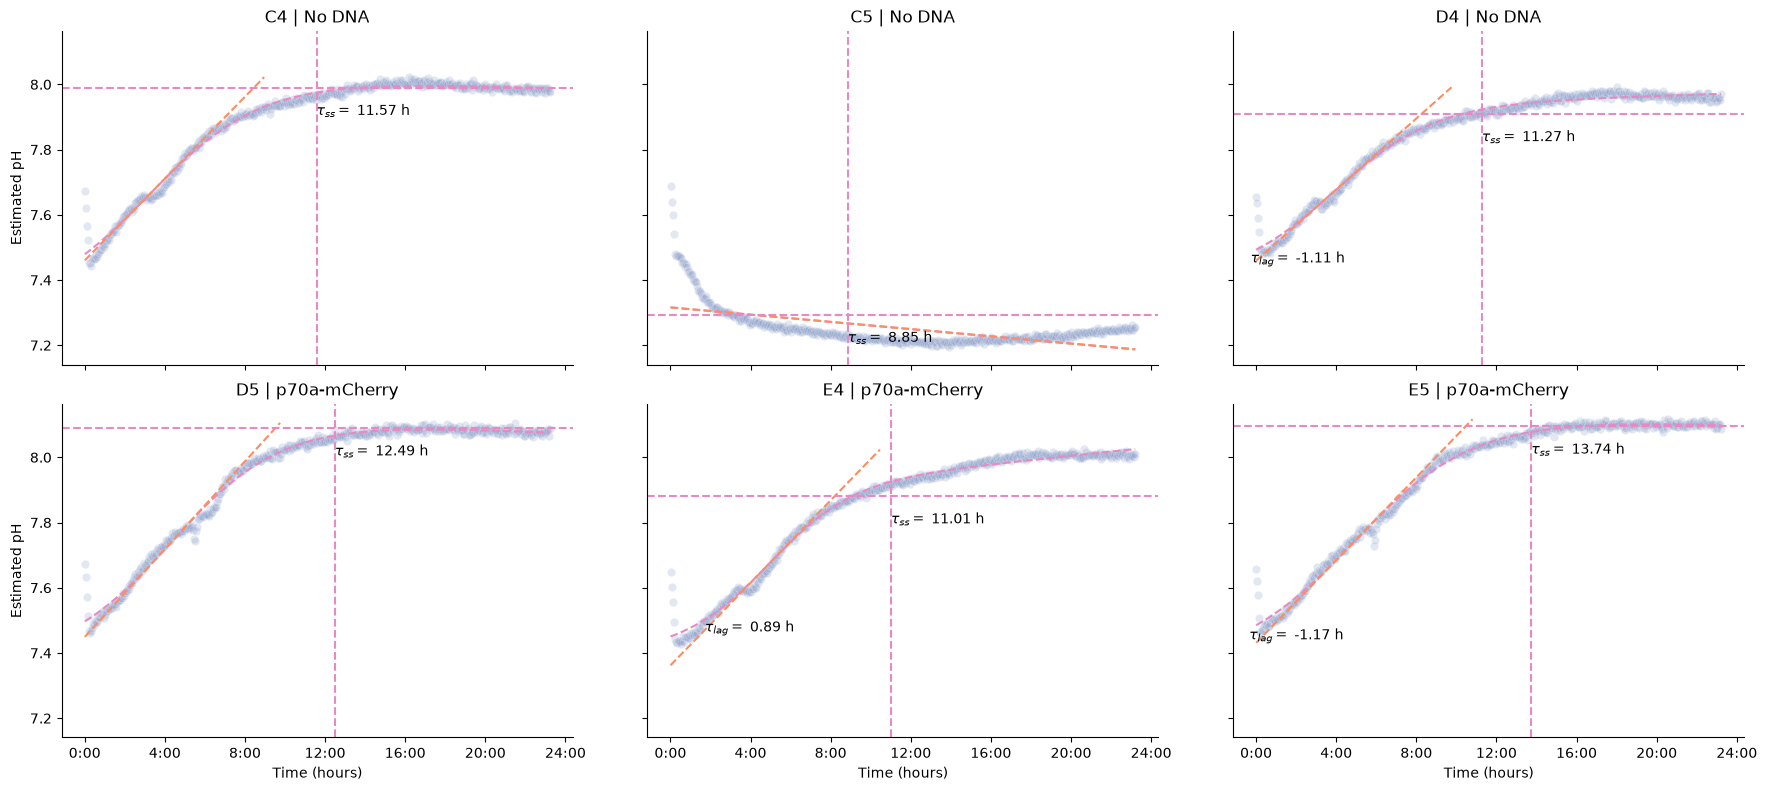

In [22]:
#| label: pH-vs-time

kinetics.plot(col="Well")

## Interpreting the kinetics

The fit is in **pH units**, so the derived metrics read directly as pH:

- **Max Velocity** — peak rate of acidification/alkalinization, in pH per hour.
- **Lag Time** — time before the response takes off.
- **Steady State** — the plateau pH. Because `sigmoid_drift_offset` fits a
  baseline `c`, this sits on the real pH baseline rather than near zero.
- **Completion Time** — when the response reaches its completion threshold.
- **R²** / **Good Fit** — fit quality; inspect wells flagged `Good Fit == False`.

Note that well C5 does not fit (`Good Fit == False`); its trace is effectively
flat, so the sigmoid model has no transition to fit.

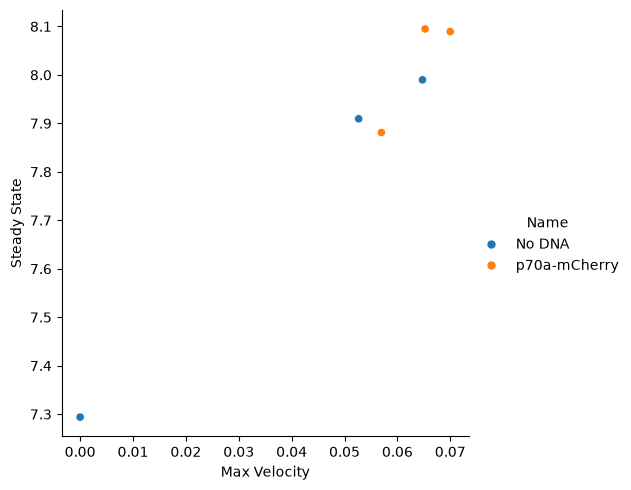

In [23]:
kinetics.plot_response(x="Max Velocity", y="Steady State", hue="Name")